# Summarisation and Controlled Text Generation with T-5

In this notebook, we will see how to fine-tune one of the [HuggingFace Transformers](https://github.com/huggingface/transformers) model (T5) for the summarisation task and the task of controlled text generation with keywords. We will use the [XSum dataset](https://arxiv.org/pdf/1808.08745.pdf) (for extreme summarisation) which contains long BBC articles and their single-sentence summaries.

[T5](https://paperswithcode.com/method/t5) is a popular model, which is designed as a text-to-text multi-task model. For each task, both input and output is text (so that for a regression task, a number 2.5 becomes a string "2.5"). Hence we can use the same model for a range of tasks including translation, linguistic acceptability, sentence similarity, document summarisation (our case), etc.

We will start by installing 🤗 Huggingface Transformers and 🤗 Huggingface Datasets as well as other dependencies.

Much of our code is based on the [official tutorial](https://colab.research.google.com/github/huggingface/notebooks/blob/main/examples/summarization-tf.ipynb).

In [52]:
! pip install transformers
! pip install -U datasets evaluate
! pip install rouge-score nltk
! pip install huggingface_hub

## Loading the Dataset




We will use the [HuggingFace Datasets](https://github.com/huggingface/datasets) library to download the data. This a very good resource for easy manipulation of commonly used datasets.

In [53]:
!datasets-cli env


Copy-and-paste the text below in your GitHub issue.

- `datasets` version: 4.7.0
- Platform: Linux-6.6.113+-x86_64-with-glibc2.35
- Python version: 3.12.12
- `huggingface_hub` version: 1.6.0
- PyArrow version: 23.0.1
- Pandas version: 2.2.2
- `fsspec` version: 2025.3.0



In [54]:
from datasets import load_dataset

# If the training time is too much and you do not have GPU / TPU then uncomment the below line and re-run the notebook
# Note that here we are reducing the size of the dataset hence the values are going to be different then what you will see when you run it on full dataset
# original_datasets = load_dataset("xsum", trust_remote_code=True, split="validation[:2%]")
original_datasets = load_dataset("xsum", trust_remote_code=True, split="validation[:10%]")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'xsum' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'xsum' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


We will further create a train and a validation set by splitting the original validation set.

In [55]:
import datasets as ds

# We will use only the validation set due to the lack of computational resources
# Split the initial validation set
train_valid = original_datasets.train_test_split(test_size=0.25)

# Gather the sets into a single DatasetDict
raw_datasets = ds.DatasetDict({'train': train_valid['train'], 'validation': train_valid['test']})

In [56]:
print(raw_datasets["train"][0])

{'document': "Gwent Police said the man was arrested in Hamburg on 12 August and will be extradited to the UK.\nThe man is believed to be Thomas Doran, who is wanted as part of Gwent Police's Operation Imperial - an investigation into serious offences against vulnerable adults on the Gwent Levels.\nThe extradition process can take six weeks, police added.", 'summary': 'A 60-year-old man from Cardiff has been arrested in Germany on suspicion of conspiracy to kidnap.', 'id': '37182451'}


### Some Data Analysis

Here we will perform some basic exploratory data analysis by computing the mean and standard deviation of token counts for the source and target documents.

The `show_random_elements` method below displays a table containing `num_examples` samples from the specified `dataset`, with fields `document`, `summary` and `id`

**Task 1: Summarisation data statistics**

Complete the functions below by tokenising the documents (the best option would be to use the tokeniser but here you can just split on spaces) and print the mean token count and standard deviation for source and target documents for each dataset. Plot histograms of the source and target token counts (method `show_token_counts` is provided). Comment on the lengths of input and target texts for summarisation.

,document,summary,id
0,"A spokesman for the governor in Nangahar province said an Afghan commando had opened fire on the US troops during a joint operation in Achin. He was shot dead in return fire.\nAnother US soldier was reportedly wounded in the attack.\nA spokesman for the Taliban said it had carried out the attack.\nIslamic State militants also operate in the area.\nEarlier, at least two Afghan policemen were killed by US forces in a so-called friendly fire incident in southern Afghanistan.\nThe deaths are said to have occurred when a US aircraft returned fire during a joint operation in the restive province of Helmand.\nIt is reported to be the first friendly fire incident in Helmand since US Marines returned there in May.\nTaliban insurgents have made widespread gains in the province.\nIn a statement, the US military apologised for the incident and said that an investigation had been launched.\nIt happened as police were on patrol in volatile Nad Ali district. The dead were members of the Afghan Border Police.\nAfghan officials told AFP news agency that the policemen were patrolling too close to a Taliban base prior to the attack. They say a number of militants were also killed in the strike.\nIn recent months, the Taliban have captured several districts in Helmand and put provincial capital Lashkar Gah under pressure.\nThe arrival of hundreds of US Marines - following the withdrawal of US troops three years ago - is part of the Nato-led effort to train and assist Afghan forces. They include special forces who conduct separate counter-terrorism operations.\nAir strikes by US warplanes have risen significantly over the last few months as President Donald Trump and other foreign leaders come under pressure to commit more troops.\nAfghanistan has been hit by numerous violent attacks in recent weeks with the launch of the Taliban's spring offensive, including a massive bomb attack in the capital, Kabul, that killed more than 150 people.","Three US special forces soldiers have been shot dead by an Afghan colleague during an operation in eastern Afghanistan, US officials say.",40232491
1,"9 December 2014 Last updated at 16:43 GMT\nMrs Mujuru, once seen as a future possible leader, has denied plotting against the president.\nState media and Mr Mugabe's wife, Grace, have conducted a campaign against her for months.\nBBC Africa reviews the demise of Mr Mugabe's main opponents - in 90 seconds.\nVideo produced by Baya Cat","President Robert Mugabe of Zimbabwe has sacked his Vice-President, Joice Mujuru, after accusing her of plotting to kill him.",30231579
2,"Media playback is not supported on this device\nYu, 29, took the final three frames, closing with breaks of 66 and 70, for a 6-4 victory and a place in the last 32.\nWorld champion Mark Selby held his nerve to see off world number 68 Daniel Wells 6-4 after trailing 4-3.\nScotland's three-time champion John Higgins came back from 3-2 down to beat Thailand's Noppon Saengkham 6-4.\nWelshman Mark Williams eased past England's Andrew Higginson 6-2, while Matthew Stevens beat Michael White 6-4 in an all-Welsh contest.\nEngland's Ali Carter beat Robbie Williams 6-2, but fellow Englishman Barry Hawkins went down 6-5 to Ireland's Fergal O'Brien, who made five centuries including three in a row at one stage.\nMedia playback is not supported on this device\n""It was a battle,"" Selby told World Snooker.\n""My focus dipped in and out. It is still the early stages of the tournament, I don't want to peak too soon.""\nHiggins won four of the last five frames to overcome Saengkham, ranked 69 places below him at 73 in the world.\n""I dodged a bullet there, I'm just delighted to get through,"" said Higgins.\n""I really did think I'd be heading up the road when I went 4-3 down. A lot of these boys are not frightened of top players any more. I felt as if the luck had ran out but the luck's still with me just now.""\nSign up to My Sport to follow snooker news and reports on the BBC app.\nMedia pl

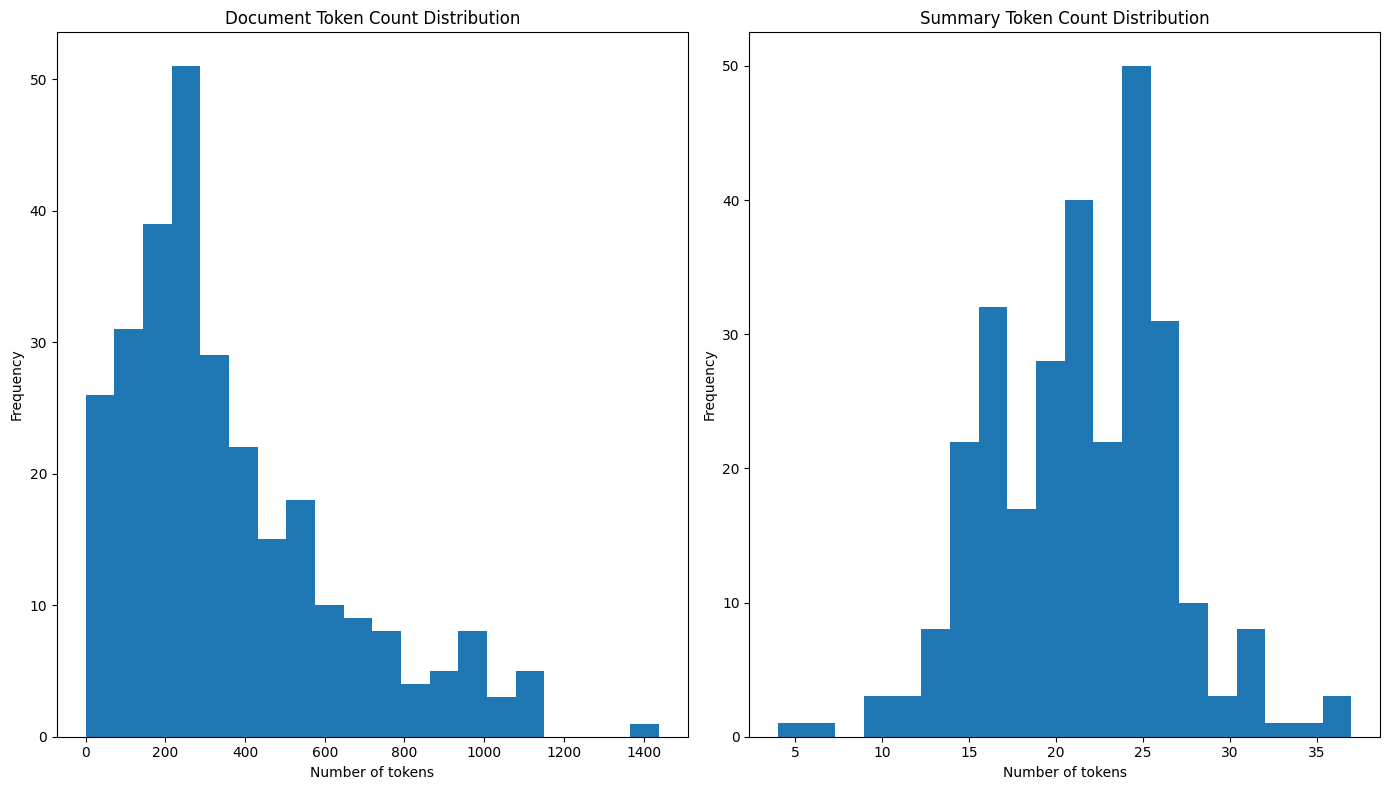


Dataset split: train

Source Documents:
Mean token count       : 374.81
Standard deviation     : 317.63

Target Summaries:
Mean token count       : 20.96
Standard deviation     : 5.28

Dataset split: validation

Source Documents:
Mean token count       : 365.64
Standard deviation     : 270.88

Target Summaries:
Mean token count       : 21.43
Standard deviation     : 5.19


In [57]:
import datasets
import random
import pandas as pd
import numpy as np
from IPython.display import display, HTML
import matplotlib.pyplot as plt

def show_random_elements(dataset, num_examples=5):

    assert num_examples <= len(dataset), "Can't pick more elements than there are in the dataset."

    picks = []
    for _ in range(num_examples):
        pick = random.randint(0, len(dataset) - 1)
        while pick in picks:
            pick = random.randint(0, len(dataset) - 1)
        picks.append(pick)

    df = pd.DataFrame(dataset[picks])

    # If the dataset contains class labels, convert numeric ids to label names
    for column, typ in dataset.features.items():
        if isinstance(typ, datasets.ClassLabel):
            df[column] = df[column].transform(lambda i: typ.names[i])

    display(HTML(df.to_html()))


"""
Task 1

Begin
"""

def calculate_token_counts(dataset):


    # List to store the number of tokens in each source document
    source_counts = []

    # List to store the number of tokens in each target summary
    target_counts = []

    # Loop through every example in the dataset
    for example in dataset:
        # Extract the source document text
        source_text = example["document"]

        # Extract the target summary text
        target_text = example["summary"]

        # Tokenise by splitting on space
        source_tokens = source_text.split()
        target_tokens = target_text.split()

        # Counting the number of tokens and store them
        source_counts.append(len(source_tokens))
        target_counts.append(len(target_tokens))

    return source_counts, target_counts


def token_counts_summary(raw_datasets):


    # Loop through each split in the dataset dictionary

    for split_name in raw_datasets.keys():

        # Getting token counts for the current split
        source_counts, target_counts = calculate_token_counts(raw_datasets[split_name])

        # Compute mean and standard deviation for source documents
        source_mean = np.mean(source_counts)
        source_std = np.std(source_counts)

        # Compute mean and standard deviation for target summaries
        target_mean = np.mean(target_counts)
        target_std = np.std(target_counts)


        print(f"\n{'=' * 50}")
        print(f"Dataset split: {split_name}")
        print(f"{'=' * 50}")

        print("\nSource Documents:")
        print(f"Mean token count       : {source_mean:.2f}")
        print(f"Standard deviation     : {source_std:.2f}")

        print("\nTarget Summaries:")
        print(f"Mean token count       : {target_mean:.2f}")
        print(f"Standard deviation     : {target_std:.2f}")


"""
End Task 1
"""

def show_token_counts(dataset):
    """
    Plot histograms of token counts for:
    - source documents
    - target summaries
    """

    # Get token counts
    source_counts, target_counts = calculate_token_counts(dataset)

    # Create a figure with 1 row and 2 columns
    f, (ax0, ax1) = plt.subplots(1, 2, figsize=(14, 8))

    # Plot histogram for document token counts
    ax0.hist(source_counts, bins=20)
    ax0.set_title("Document Token Count Distribution")
    ax0.set_xlabel("Number of tokens")
    ax0.set_ylabel("Frequency")

    # Plot histogram for summary token counts
    ax1.hist(target_counts, bins=20)
    ax1.set_title("Summary Token Count Distribution")
    ax1.set_xlabel("Number of tokens")
    ax1.set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()


# Display a few random samples from the validation set
show_random_elements(raw_datasets["validation"])

# Plot token count histograms for the validation set
show_token_counts(raw_datasets["validation"])

# Print mean and standard deviation for both train and validation splits
token_counts_summary(raw_datasets)


### ROUGE Metric

To evaluate our model's performance, we will use **ROUGE (Recall-Oriented Understudy for Gisting Evaluation)**. It compares *n*-grams of the model outputs to reference text but is based on recall instead of precision like BLEU. ROUGE does not impose any brevity penalty. BLEU returns a single number, ROUGE outputs multiple scores per each $n$-gram under consideration.

This metric is provided natively within the dataset library. **Note** metrics are difficult to implement correctly from scratch as decisions like lemmatisation, tokenisation and punctation-handling can create large discrepancies in scores.

You can call its `compute` method with your hypotheses and target summaries, which need to be list of decoded strings:

In [58]:
import evaluate
metric = evaluate.load("rouge", trust_remote_code=True)

# help(metric)      # << Uncomment to see more about the ROUGE eval metric

predicted_summaries = ["AI applications span diverse fields.", "Enhancing efficiency, decision-making, experiences with AI."]
target_doc = 'As artificial intelligence continues to advance, researchers are exploring its applications in diverse fields such as healthcare, finance, education, and entertainment, aiming to improve efficiency, decision-making processes, and overall human experiences.'
docs = [target_doc, target_doc]

metric.compute(predictions=predicted_summaries, references=docs)

{'rouge1': np.float64(0.18364518364518362),
 'rouge2': np.float64(0.08262548262548262),
 'rougeL': np.float64(0.18364518364518362),
 'rougeLsum': np.float64(0.18364518364518362)}

## Preprocessing the Data

We will proprocess the data using the Huggingface `Tokenizer` paired with T5, which tokenises input text and adds additional required tokens. This ensures that our inputs are correctly aligned with the model's embedding matrix.

In [59]:
from transformers import AutoTokenizer

model_checkpoint = "t5-small"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

### Using the Tokenizer

`Tokenizer` outputs are different for different tokenisers. Compare outputs below for the T5 and BERT tokenisers.


In [60]:
print(tokenizer("AI applications span diverse fields."))

tokenizer_ = AutoTokenizer.from_pretrained('bert-base-uncased')
tokenizer_('AI applications span diverse fields.')

{'input_ids': [7833, 1564, 8438, 2399, 4120, 5, 1], 'attention_mask': [1, 1, 1, 1, 1, 1, 1]}


{'input_ids': [101, 9932, 5097, 8487, 7578, 4249, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1]}

As we mentioned above, T5 was trained in a multitask setup such that it can perform multiple tasks. We prefix the inputs with "summarize: " to prompt the model to summarise.

We will now create a function to preprocess our samples, feeding them to the tokeniser with the `truncation=True` argument. This ensures that any input exceeding the model's maximum accepted length will be truncated accordingly. Padding will be addressed later in a data collator, allowing us to pad examples to the longest length in the batch rather than the entire dataset.

Complete the `preprocess_function` below to prepare our training data (**Hint**: do not forget to prefix the inputs).

In [61]:
if model_checkpoint in ["t5-small", "t5-base", "t5-large", "t5-3b", "t5-11b"]:
    prefix = "summarize: "
else:
    prefix = ""

In [62]:
if model_checkpoint in ["t5-small", "t5-base", "t5-large", "t5-3b", "t5-11b"]:
    prefix = "summarize: "
else:
    prefix = ""

max_doc_len = 1024
max_sum_length = 128


def preprocess_samples(samples):

    inputs = list()

    """
    Task 2 1/3

    Begin
    """

    # Add the T5 task prefix to every input document

    inputs = [prefix + doc for doc in samples["document"]]

    # Tokenize the input documents
    # truncation=True ensures inputs longer than max_doc_len are cut off
    model_inputs = tokenizer(
        inputs,
        max_length=max_doc_len,
        truncation=True
    )

    """
    End Task 2 1/3
    """

    # Tokenize the target summaries

    targets = tokenizer(
        text_target=samples["summary"],
        max_length=max_sum_length,
        truncation=True
    )

    # Store target token ids in "labels" so the model knows what to predict
    model_inputs["labels"] = targets["input_ids"]

    return model_inputs


This function works with one or several examples. In the case of several examples, the tokeniser will return a list of lists for each key:

In [63]:
raw_datasets["train"][:2]

{'document': ["Gwent Police said the man was arrested in Hamburg on 12 August and will be extradited to the UK.\nThe man is believed to be Thomas Doran, who is wanted as part of Gwent Police's Operation Imperial - an investigation into serious offences against vulnerable adults on the Gwent Levels.\nThe extradition process can take six weeks, police added.",
  "Officials laid wreaths at a memorial to victims of the Ustashe puppet regime, which incarcerated Jews, Serbs and others in brutal conditions.\nHowever, the service at Jasenovac was boycotted by Jewish and Serb groups.\nThey say the new Croat government has not acted against renewed use of Ustashe salutes by nationalists.\nIn January, ultra-nationalists shouted pro-Nazi slogans at a rally attended by thousands of people, including Deputy Parliamentary Speaker Ivan Tepes.\nSimilar slogans were also chanted during a football match between Israel and Croatia in March, attended by Prime Minister Tihomir Oreskovic.\nCroatia's Jewish c

In [64]:
preprocess_samples(raw_datasets["train"][:2])

{'input_ids': [[21603, 10, 350, 16103, 5076, 243, 8, 388, 47, 10195, 16, 7330, 30, 586, 1660, 11, 56, 36, 996, 10700, 26, 12, 8, 1270, 5, 37, 388, 19, 6141, 12, 36, 3576, 6200, 152, 6, 113, 19, 1114, 38, 294, 13, 350, 16103, 5076, 31, 7, 6411, 1575, 21268, 3, 18, 46, 4962, 139, 2261, 10883, 2319, 581, 9930, 3513, 30, 8, 350, 16103, 7166, 7, 5, 37, 996, 10569, 433, 54, 240, 1296, 1274, 6, 2095, 974, 5, 1], [21603, 10, 13686, 7, 7245, 25070, 7, 44, 3, 9, 15827, 12, 8926, 13, 8, 412, 2427, 7, 88, 26141, 10030, 6, 84, 3, 14736, 15, 4094, 11896, 6, 5631, 115, 7, 11, 717, 16, 14506, 1124, 5, 611, 6, 8, 313, 44, 2215, 7, 35, 32, 8938, 47, 30242, 15, 26, 57, 6692, 11, 5631, 115, 1637, 5, 328, 497, 8, 126, 5811, 144, 789, 65, 59, 3, 9925, 581, 18184, 169, 13, 412, 2427, 7, 88, 20239, 15, 7, 57, 1157, 343, 7, 5, 86, 1762, 6, 6173, 18, 16557, 343, 7, 14314, 15, 26, 813, 18, 567, 9, 702, 22031, 7, 44, 3, 9, 13980, 5526, 57, 2909, 13, 151, 6, 379, 3, 16911, 12876, 1208, 16778, 27, 2132, 2255, 855, 

We will apply the `map` method of our `raw_datasets` object we created earlier. This will apply the function on all the elements of all the splits in `dataset`, so our training, validation and testing data will be preprocessed in one single command.

In [65]:
preprocessed_datasets = raw_datasets.map(preprocess_samples, batched=True, remove_columns=raw_datasets["train"].column_names)

Map:   0%|          | 0/849 [00:00<?, ? examples/s]

Map:   0%|          | 0/284 [00:00<?, ? examples/s]

The outcomes are automatically stored in the 🤗 Datasets library's cache, so that processing does not need to be repeated. If you need to reapply preprocessing, you can include `load_from_cache_file=False` in the map function call.

We specified `batched=True `to encode texts in batches which employs multi-threading.

## Fine-tuning T5

We will now download the pretrained model and fine-tune it. Since our task is sequence-to-sequence, we use the `AutoModelForSeq2SeqLM` class.

In [66]:
from transformers import AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq

model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Let's set the learning rate, `batch_size` and customise the weight decay.

In [67]:
batch_size = 8
learning_rate = 2e-5
weight_decay = 0.01
num_train_epochs = 5

model_name = model_checkpoint.split("/")[-1]
push_to_hub_model_id = f"{model_name}-finetuned-xsum"

Next, we build a data collator that pads the inputs to the batch's maximum length for both inputs ans targets. Make sure to set the `return_tensors='np'` argument to obtain NumPy arrays. Our TensorFlow dataset pipeline internally employs a NumPy loader, wrapped with a tf.data.Dataset at the end. Additionally, np is required by the ROUGE metrics.


To speed up GPU computation, we specify `pad_to_multiple_of`, which snaps the padding length to the next multiple of the given value. For example, if we pad to 250 but pad_to_multiple_of=8 then we will pad to 256.

In [68]:
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, return_tensors="pt")

generation_data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, return_tensors="pt", pad_to_multiple_of=128)

We will convert our datasets into tf.data.Dataset, to be able to work with Keras. We will use Model.prepare_tf_dataset() to avoid manual specification. We re-use the collator we created earlier as our `collate_fn`.

In [69]:
from torch.utils.data import DataLoader
from datasets import Dataset

# Convert datasets to PyTorch format
train_dataset = preprocessed_datasets["train"]
validation_dataset = preprocessed_datasets["validation"]

# Create DataLoaders for training and validation
train_dataloader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, collate_fn=data_collator
)

validation_dataloader = DataLoader(
    validation_dataset, batch_size=batch_size, shuffle=False, collate_fn=data_collator
)

In [70]:
train_dataset

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 849
})

Now we initialise our loss and optimizer and compile the model.

In [71]:
from torch.optim import AdamW

# Define optimizer
optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

Finally, we can train our model. KerasMetricCallback is a callback for computing advanced metrics. The callback takes two main arguments: `metric_fn` and `eval_dataset`. It then iterates the `eval_dataset` and collects the model's outputs for each sample. As a result, the callback passes the `list` of predictions and the associated `list` of targets to the user-defined `metric_fn`. If the `predict_with_generate` argument is `True`, then it will call `model.generate()`. This is useful for metrics like `ROUGE`.

Complete the `compute_metrics` below to decode output batches and compute ROUGE (**Hint**: you can use `tokenizer.batch_decode` and `metric.compute`).

In [72]:
# Evaluation metrics
def compute_metrics(eval_predictions):
    model_predictions, true_labels = eval_predictions

    # Replace masked true label tokens with pad token id
    # so they can be decoded into text safely
    for label in true_labels:
        label[label < 0] = tokenizer.pad_token_id

    """
    Task 2 2/3

    Begin
    """
    # Decode model predictions from token ids to normal text
    decoded_predictions = tokenizer.batch_decode(
        model_predictions, skip_special_tokens=True
    )

    # Decode true labels from token ids to normal text
    decoded_labels = tokenizer.batch_decode(
        true_labels, skip_special_tokens=True
    )

    # ROUGE expects sentence boundaries more clearly,so we insert a newline after each sentence
    decoded_predictions = [
        "\n".join(nltk.sent_tokenize(pred.strip())) for pred in decoded_predictions
    ]
    decoded_targets = [
        "\n".join(nltk.sent_tokenize(label.strip())) for label in decoded_labels
    ]

    # Compute ROUGE scores by comparing predictions with true summaries
    rouge_results = metric.compute(
        predictions=decoded_predictions,
        references=decoded_targets,
        use_stemmer=True
    )

    """
    End Task 2 2/3
    """

    # Convert ROUGE score objects into percentage values
    rouge_results = {key: value.mid.fmeasure * 100 for key, value in rouge_results.items()}

    # Compute average generated summary length
    prediction_lengths = [
        np.count_nonzero(pred != tokenizer.pad_token_id) for pred in model_predictions
    ]
    rouge_results["gen_len"] = np.mean(prediction_lengths)

    return rouge_results


We will train our model now. We only do five epochs, as inputs are very long and even one epoch can take a while.

In [73]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [74]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Training loop
for epoch in range(num_train_epochs):
    model.train()
    model.to(device)
    for batch in train_dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch + 1}: Training loss: {loss.item()}")

Epoch 1: Training loss: 3.2917304039001465
Epoch 2: Training loss: 2.166411876678467
Epoch 3: Training loss: 1.7484947443008423
Epoch 4: Training loss: 2.5664100646972656
Epoch 5: Training loss: 2.2291784286499023


In [82]:
# --- Validation ROUGE after fine-tuning ---
model.eval()

val_predictions = []
val_references = []

for example in raw_datasets["validation"]:
    inputs = tokenizer(
        prefix + example["document"],
        return_tensors="pt",
        truncation=True,
        max_length=max_doc_len
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        output_ids = model.generate(**inputs, max_length=128)

    pred = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    ref = example["summary"]

    val_predictions.append(pred)
    val_references.append(ref)

val_rouge = metric.compute(
    predictions=val_predictions,
    references=val_references,
    use_stemmer=True
)

print("Validation ROUGE after fine-tuning:")
print(val_rouge)


Validation ROUGE after fine-tuning:
{'rouge1': np.float64(0.25013430383046664), 'rouge2': np.float64(0.054476583246278375), 'rougeL': np.float64(0.18753827511721322), 'rougeLsum': np.float64(0.18793947006518857)}


## Inference

Let's try now to summarise a document using our model. Do not forget to prepend "summarize: " to the input.

In [75]:
# Choose one example from the validation set
document = raw_datasets["validation"][0]["document"]
summary = raw_datasets["validation"][0]["summary"]

"""
Task 2 3/3

Begin
"""
tokenized = tokenizer(
    prefix + document,
    return_tensors="pt",
    truncation=True,
    max_length=max_doc_len
)

tokenized = {k: v.to(device) for k, v in tokenized.items()}
"""
End Task 2 3/3
"""

out = model.generate(**tokenized, max_length=128)

generated_summary = tokenizer.decode(out[0], skip_special_tokens=True)

print("Reference summary:\n", summary)
print("\nGenerated summary:\n", generated_summary)


Reference summary:
 A 90-minute match but only 47 minutes and 40 seconds of actual football.

Generated summary:
 The Premier League has been a fixture in the Premier League since the start of the season.


In [76]:
out_ft = tokenizer.decode(out[0], skip_special_tokens=True)
print(out_ft)

The Premier League has been a fixture in the Premier League since the start of the season.


## Pipeline API

The pipeline API provides a convienient shortcut to many procedures. Let's use it to generate a summary with the non fine-tuned model.

In [77]:
"""
from transformers import pipeline

# we will use the initial T5 checkpoint we downloaded before fine-tuning
summarizer = pipeline('text2text-generation', model_checkpoint, framework="pt", device=device)

"""

# NOTE:
# The notebook is using the HuggingFace pipeline with the task
# "text2text-generation". However, the installed Transformers version
# in this environment no longer supports this pipeline task for T5 models.
# Therefore, the summarisation was performed directly using model.generate()
# and tokenizer.decode(), which is the standard way to run inference for
# sequence-to-sequence models.

# Load the original pretrained model again

from transformers import AutoModelForSeq2SeqLM

# Load a fresh pretrained T5 model (not fine-tuned)
base_model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint).to(device)
base_model.eval()

# Same validation example
document = raw_datasets["validation"][0]["document"]
summary = raw_datasets["validation"][0]["summary"]

# Tokenize input
tokenized_base = tokenizer(
    prefix + document,
    return_tensors="pt",
    truncation=True,
    max_length=max_doc_len
)

tokenized_base = {k: v.to(device) for k, v in tokenized_base.items()}

# Generate non-fine-tuned summary
with torch.no_grad():
    out_base = base_model.generate(**tokenized_base, max_length=128)

out_zero_shot = tokenizer.decode(out_base[0], skip_special_tokens=True)

print("Reference summary:\n", summary)
print("\nNon-fine-tuned summary:\n", out_zero_shot)


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Reference summary:
 A 90-minute match but only 47 minutes and 40 seconds of actual football.

Non-fine-tuned summary:
 a number of premier league games have seen less action this season. the league has been dominated by possession statistics. the league has been dominated by possession statistics.


**Task 2: Compare performance of the fine-tuned model to generic output**

Summarise the document provided above using the generic model (no fine-tuning). Compute ROUGE scores and comment on the efficiency of fine-tuning.

In [78]:
'''
out = summarizer(document, max_length=128)
out_zero_shot = out[0]['generated_text']
print(out_zero_shot)

'''

# Fine-tuned summary (already generated earlier)
out_ft = generated_summary
print("Fine-tuned summary:\n", out_ft)

# Reference summary from dataset
summary = raw_datasets["validation"][0]["summary"]



Fine-tuned summary:
 The Premier League has been a fixture in the Premier League since the start of the season.


In [79]:
metric.compute(predictions=[out_ft], references=[summary])

{'rouge1': np.float64(0.12903225806451615),
 'rouge2': np.float64(0.0),
 'rougeL': np.float64(0.12903225806451615),
 'rougeLsum': np.float64(0.12903225806451615)}

In [80]:
metric.compute(predictions=[out_zero_shot], references=[summary])

{'rouge1': np.float64(0.09523809523809523),
 'rouge2': np.float64(0.0),
 'rougeL': np.float64(0.09523809523809523),
 'rougeLsum': np.float64(0.09523809523809523)}

## Textual data generation using keywords


One possible way to generate new text for data augmentation is to guide the generation of new text using keywords extracted from original data. In this task, you will fine-tune T5 to generate new text based on keywords extracted from the original summaries of the XSum dataset you have seen in the first part of this lab.  Fine-tuning T5 on such a task would leverage the model capabilities to produce new text that captures the core meaning of the original based on the provided keywords.

**Task 3: Build and evaluate a T5-based model for data generation using keywords.**

Complete the `preprocess_samples_data_gen` below to extract 20 random words from each summary. Those random words will be further tokenised and used as inputs to T5. Note that in this task you do not need to prepend "summarize: ".

In [84]:
import random

def preprocess_samples_data_gen(samples):

    inputs = list()
    """
    Task 3

    Begin
    """
    for doc in samples["summary"]:
        # split summary into words
        words = doc.split()

        # choosing 20 random words
        selected_words = random.sample(words, min(20, len(words)))

        # joining selected words back into a single string
        keyword_input = " ".join(selected_words)

        # storing as model input
        inputs.append(keyword_input)

    """
    End Task 3
    """

    model_inputs = tokenizer(inputs, max_length=max_doc_len, truncation=True)
    targets = tokenizer(text_target=samples["summary"], max_length=max_sum_length, truncation=True)

    model_inputs["labels"] = targets["input_ids"]

    return model_inputs


Now we can preprocess, collate and prepare our new dataset in the similar way we have done before.

In [85]:
preprocessed_datasets_data_gen = raw_datasets.map(preprocess_samples_data_gen, batched=True, remove_columns=raw_datasets["train"].column_names)

Map:   0%|          | 0/849 [00:00<?, ? examples/s]

Map:   0%|          | 0/284 [00:00<?, ? examples/s]

In [86]:
from transformers import AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq

model_data_gen = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

In [87]:
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model_data_gen, return_tensors="pt")

generation_data_collator = DataCollatorForSeq2Seq(tokenizer, model=model_data_gen, return_tensors="pt", pad_to_multiple_of=128)

In [88]:
train_dataset = preprocessed_datasets_data_gen["train"]

# Create DataLoaders for training
train_dataloader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, collate_fn=data_collator
)


Now we initialise our loss and optimizer and compile the model. Note that most Transformers models compute loss internally, so we do not need to specify any loss when we `compile()`.

In [89]:
from torch.optim import AdamW

# Define optimizer
optimizer = AdamW(model_data_gen.parameters(), lr=learning_rate, weight_decay=weight_decay)

We will finally fine-tune our model for five epochs.

In [90]:
# Training loop
num_train_epochs = 5
for epoch in range(num_train_epochs):
    model_data_gen.train()
    model_data_gen.to(device)
    for batch in train_dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model_data_gen(**batch)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch + 1}: Training loss: {loss.item()}")

Epoch 1: Training loss: 2.836674928665161
Epoch 2: Training loss: 1.337863802909851
Epoch 3: Training loss: 4.8564348220825195
Epoch 4: Training loss: 1.981372356414795
Epoch 5: Training loss: 2.2884602546691895


Let's try now to generate a document using pre-set keywords. We again do not need to prepend the 'summarize:' prompt.

In [91]:
document = 'damage ongoing Hawick disruption Lamington viaduct commercial thoroughfare multi-agency neglected'

tokenized = tokenizer([document], return_tensors='pt').to(device)
out = model_data_gen.generate(**tokenized, max_length=128)

In [92]:
out_ft = tokenizer.decode(out[0], skip_special_tokens=True)
print(out_ft)

Hawick has been stranded in a hammer in Lamington via a commercial thoroughfare multi-agency network neglected and neglected by Hawick.
